# 08 - Buffered Callaway-Sant'Anna ATT

This notebook estimates the main direct effect using a library-compatible buffered donor pool. It uses `diff-diff` as the main implementation and compares the no-covariate specification with `csdid`.

In [11]:
from pathlib import Path
import json
import math
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'notebooks').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.estimation_workflow_utils import append_tag_to_filename, build_stable_buffered_did_panel, hac_for_group_time_effects

DATA_DIR = PROJECT_ROOT / 'data'
INTERMEDIATE_DIR = DATA_DIR / 'intermediate'
SPATIAL_DIR = INTERMEDIATE_DIR / 'spatial_structure'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIG_DIR = OUTPUT_DIR / 'figures'
for path in [INTERMEDIATE_DIR, TABLE_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)


Project root: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2


## User configuration

In [24]:
RUN_TAG = '1km'
START_YEAR = 2001
END_YEAR = None
TREATMENT_KEY = 'protected_area'
CELL_COL = 'cell_id'
YEAR_COL = 'year'
OUTCOME_COL = 'loss_m2'
MAIN_BUFFER_KM = 25
BUFFER_RADII_KM = [10, 25, 50]

PANEL_PATH = INTERMEDIATE_DIR / f'panel_treatment_{RUN_TAG}.parquet'
if not PANEL_PATH.exists():
    PANEL_PATH = INTERMEDIATE_DIR / 'panel_treatment.parquet'
EXPOSURE_PATH = INTERMEDIATE_DIR / append_tag_to_filename('06_nearest_treated_exposure.parquet', RUN_TAG)
CENTROID_PATH = SPATIAL_DIR / append_tag_to_filename('03_grid_centroids.parquet', RUN_TAG)
if not CENTROID_PATH.exists():
    CENTROID_PATH = SPATIAL_DIR / '03_grid_centroids.parquet'
USE_CORE_COVARIATES = False
USE_ROBUST_COVARIATES = False
CORE_COVARIATE_PATH = INTERMEDIATE_DIR / append_tag_to_filename('panel_core_covariates.parquet', RUN_TAG)
ROBUST_COVARIATE_PATH = INTERMEDIATE_DIR / append_tag_to_filename('panel_robustness_covariates.parquet', RUN_TAG)

ESTIMATION_SAMPLE_NAME = '08_buffered_estimation_panel.parquet'
DIFFDIFF_RESULTS_NAME = '08_diffdiff_cs_results.csv'
DIFFDIFF_OVERALL_NAME = '08_diffdiff_overall_att.csv'
COHORT_EFFECTS_NAME = '08_diffdiff_cohort_effects.csv'
COHORT_HAC_SE_COMPARISON_NAME = '08_diffdiff_cohort_hac_se_comparison.csv'
OVERALL_HAC_SE_COMPARISON_NAME = '08_diffdiff_overall_hac_se_comparison.csv'
HAC_SE_COMPARISON_NAME = '08_diffdiff_hac_se_comparison.csv'
CSDID_RESULTS_NAME = '08_csdid_comparison_results.csv'
COMPARISON_NAME = '08_diffdiff_csdid_comparison.csv'
SPATIAL_HAC_NAME = '08_spatial_hac_attgt.csv'
EVENT_FIG_NAME = '08_diffdiff_event_study.png'
COHORT_FIG_NAME = '08_diffdiff_cohort_effects.png'
COHORT_HAC_SE_COMPARISON_FIG_NAME = '08_diffdiff_cohort_hac_se_comparison.png'
CSDID_EVENT_COMPARISON_FIG_NAME = '08_diffdiff_csdid_event_comparison.png'
HAC_SE_COMPARISON_FIG_NAME = '08_diffdiff_hac_se_comparison.png'

# Optional cross-check. The full 1km panel can exceed memory for csdid.
RUN_CSDID_COMPARISON = True
CSDID_MAX_ROWS = 2_000_000
CSDID_ALLOW_LARGE_PANEL = True

EVENT_WINDOW_MIN = -8
EVENT_WINDOW_MAX = 5

# Optional exploratory DDD. This is not staggered; it collapses the design to a binary post period.
RUN_TRIPLE_DIFFERENCE = False
DDD_POST_YEAR = 2017
DDD_GROUP_COL = 'ever_protected_area'
DDD_PARTITION_COL = 'ever_land_title_any'
DDD_RESULTS_NAME = '08_exploratory_triple_difference.csv'

HAC_CUTOFF_KM = 25
HAC_KERNEL = 'bartlett'
HAC_MAX_PAIRS = 50_000_000


## Load and build buffered estimation sample

The library-compatible sample keeps treated cohorts with pre-treatment observations and uses never-treated controls that remain outside the chosen buffer throughout the analysis window.

In [13]:
import pyarrow.parquet as pq

first_treat_col = 'first_treat_year'
panel_schema_cols = pq.ParquetFile(PANEL_PATH).schema_arrow.names
panel_cols = [
    CELL_COL, YEAR_COL, OUTCOME_COL, first_treat_col,
    'treated_before_panel_start', 'never_treated', 'ever_treated',
    DDD_GROUP_COL, DDD_PARTITION_COL,
]
panel_cols = [c for c in panel_cols if c in panel_schema_cols]
panel = pd.read_parquet(PANEL_PATH, columns=panel_cols)
panel[CELL_COL] = panel[CELL_COL].astype('string')
panel[YEAR_COL] = pd.to_numeric(panel[YEAR_COL], errors='coerce').astype(int)
exposure = pd.read_parquet(EXPOSURE_PATH)
exposure[CELL_COL] = exposure[CELL_COL].astype('string')
exposure[YEAR_COL] = pd.to_numeric(exposure[YEAR_COL], errors='coerce').astype(int)
centroids = pd.read_parquet(CENTROID_PATH)
centroids[CELL_COL] = centroids[CELL_COL].astype('string')

did_panel = build_stable_buffered_did_panel(
    panel,
    exposure,
    buffer_km=MAIN_BUFFER_KM,
    cell_col=CELL_COL,
    year_col=YEAR_COL,
    first_treat_col=first_treat_col,
    treated_before_panel_col='treated_before_panel_start',
    outcome_col=OUTCOME_COL,
    min_year=START_YEAR,
    max_year=END_YEAR,
)
sample_path = INTERMEDIATE_DIR / append_tag_to_filename(ESTIMATION_SAMPLE_NAME, RUN_TAG)
did_panel.to_parquet(sample_path, index=False)
print('Saved:', sample_path)
print('Rows:', f'{len(did_panel):,}')
print('Cells:', f'{did_panel[CELL_COL].nunique():,}')
print('Treated cohorts:', sorted([int(x) for x in did_panel['first_treat_for_did'].unique() if x > 0])[:10], '...')


Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\intermediate\08_buffered_estimation_panel_1km.parquet
Rows: 11,714,825
Cells: 468,593
Treated cohorts: [2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011] ...


## Attach covariate sets

In [14]:
covariate_sets = {'none': []}
analysis_panel = did_panel.copy()

if USE_CORE_COVARIATES and CORE_COVARIATE_PATH.exists():
    core = pd.read_parquet(CORE_COVARIATE_PATH)
    core[CELL_COL] = core[CELL_COL].astype('string')
    core_covariates = [c for c in core.columns if c not in {CELL_COL, 'cell_lon', 'cell_lat', 'first_treat_year', 'ever_treated', 'never_treated'}]
    analysis_panel = analysis_panel.merge(core[[CELL_COL] + core_covariates], on=CELL_COL, how='left')
    covariate_sets['core'] = core_covariates

if USE_ROBUST_COVARIATES and ROBUST_COVARIATE_PATH.exists():
    robust = pd.read_parquet(ROBUST_COVARIATE_PATH)
    robust[CELL_COL] = robust[CELL_COL].astype('string')
    robust_covariates = [c for c in robust.columns if c not in {CELL_COL, 'cell_lon', 'cell_lat', 'first_treat_year', 'ever_treated', 'never_treated'}]
    analysis_panel = analysis_panel.merge(robust[[CELL_COL] + robust_covariates], on=CELL_COL, how='left')
    covariate_sets['robust'] = robust_covariates

print('Covariate paths:')
print(' - core:', CORE_COVARIATE_PATH, '| enabled:', USE_CORE_COVARIATES)
print(' - robust:', ROBUST_COVARIATE_PATH, '| enabled:', USE_ROBUST_COVARIATES)
print('Covariate sets:', {k: len(v) for k, v in covariate_sets.items()})


Covariate paths:
 - core: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\intermediate\panel_core_covariates_1km.parquet | enabled: False
 - robust: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\intermediate\panel_robustness_covariates_1km.parquet | enabled: False
Covariate sets: {'none': 0}


## Estimate with diff-diff

In [15]:
try:
    from diff_diff import CallawaySantAnna, plot_event_study
except ImportError as exc:
    raise ImportError('Install estimator dependencies with `%pip install -r ../requirements.txt` before running notebook 08.') from exc

def significance_stars(p):
    if not np.isfinite(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    if p < 0.1:
        return '.'
    return ''

def extract_diffdiff_results(result, covariate_set):
    rows = []
    if hasattr(result, 'group_time_effects'):
        effects = result.group_time_effects
    elif hasattr(result, 'results_') and hasattr(result.results_, 'group_time_effects'):
        effects = result.results_.group_time_effects
    else:
        effects = {}
    if isinstance(effects, dict):
        iterator = effects.items()
    else:
        iterator = [((getattr(eff, 'group', np.nan), getattr(eff, 'time', np.nan)), eff) for eff in effects]
    for (group, time), eff in iterator:
        if isinstance(eff, dict):
            att = eff.get('effect', eff.get('att', eff.get('estimate', np.nan)))
            se = eff.get('se', eff.get('std_error', np.nan))
        else:
            att = getattr(eff, 'effect', getattr(eff, 'att', getattr(eff, 'estimate', np.nan)))
            se = getattr(eff, 'se', getattr(eff, 'std_error', np.nan))
        rows.append({
            'covariate_set': covariate_set,
            'group': group,
            'time': time,
            'att': att,
            'se': se,
        })
    overall = getattr(result, 'overall_att', np.nan)
    overall_se = getattr(result, 'overall_se', np.nan)
    overall_t = getattr(result, 'overall_t_stat', np.nan)
    if not np.isfinite(overall_t) and np.isfinite(overall) and np.isfinite(overall_se) and overall_se > 0:
        overall_t = overall / overall_se
    overall_p = getattr(result, 'overall_p_value', np.nan)
    if not np.isfinite(overall_p) and np.isfinite(overall_t):
        overall_p = math.erfc(abs(overall_t) / math.sqrt(2.0))
    overall_ci = getattr(result, 'overall_conf_int', (np.nan, np.nan))
    return pd.DataFrame(rows), {
        'covariate_set': covariate_set,
        'overall_att': overall,
        'overall_se': overall_se,
        'overall_t': overall_t,
        'overall_p': overall_p,
        'ci_low': overall_ci[0] if overall_ci is not None else np.nan,
        'ci_high': overall_ci[1] if overall_ci is not None else np.nan,
        'significance': significance_stars(overall_p),
    }

diffdiff_rows = []
overall_rows = []
diffdiff_results = {}
for cov_name, covs in covariate_sets.items():
    model_df = analysis_panel[[CELL_COL, YEAR_COL, OUTCOME_COL, 'first_treat_for_did'] + covs].dropna().copy()
    method = 'dr' if covs else 'reg'
    estimator = CallawaySantAnna(control_group='never_treated', estimation_method=method, n_bootstrap=0, seed=123)
    fit_kwargs = dict(data=model_df, outcome=OUTCOME_COL, unit=CELL_COL, time=YEAR_COL, first_treat='first_treat_for_did')
    if covs:
        fit_kwargs['covariates'] = covs
    result = estimator.fit(**fit_kwargs)
    diffdiff_results[cov_name] = result
    gt, overall = extract_diffdiff_results(result, cov_name)
    diffdiff_rows.append(gt)
    overall_rows.append(overall)

diffdiff_gt = pd.concat(diffdiff_rows, ignore_index=True) if diffdiff_rows else pd.DataFrame()
if not diffdiff_gt.empty:
    for col in ['group', 'time', 'att', 'se']:
        diffdiff_gt[col] = pd.to_numeric(diffdiff_gt[col], errors='coerce')
    diffdiff_gt = diffdiff_gt.dropna(subset=['group', 'time', 'att']).reset_index(drop=True)
diffdiff_overall = pd.DataFrame(overall_rows)
diffdiff_path = TABLE_DIR / append_tag_to_filename(DIFFDIFF_RESULTS_NAME, RUN_TAG)
overall_path = TABLE_DIR / append_tag_to_filename(DIFFDIFF_OVERALL_NAME, RUN_TAG)
diffdiff_gt.to_csv(diffdiff_path, index=False)
diffdiff_overall.to_csv(overall_path, index=False)
print('Saved:', diffdiff_path)
print('Saved:', overall_path)
print(diffdiff_overall.to_string(index=False))


Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\tables\08_diffdiff_cs_results_1km.csv
Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\tables\08_diffdiff_overall_att_1km.csv
covariate_set  overall_att  overall_se  overall_t    overall_p      ci_low     ci_high significance
         none  -193.145718   23.247305  -8.308306 9.707799e-17 -238.709598 -147.581838          ***


## Compare no-covariate result with csdid

In [22]:
try:
    from csdid.att_gt import ATTgt
    csdid_available = True
except ImportError as exc:
    csdid_available = False
    print(f'Optional csdid cross-check unavailable: {exc}')

csdid_gt = pd.DataFrame()
if not RUN_CSDID_COMPARISON:
    print('csdid comparison skipped. Set RUN_CSDID_COMPARISON = True for the optional cross-check.')
elif not csdid_available:
    print('csdid comparison skipped.')
elif len(analysis_panel) > CSDID_MAX_ROWS and not CSDID_ALLOW_LARGE_PANEL:
    print(f'csdid comparison skipped: {len(analysis_panel):,} rows exceeds CSDID_MAX_ROWS={CSDID_MAX_ROWS:,}.')
    print('Use a coarser RUN_TAG, a smaller diagnostic sample, or set CSDID_ALLOW_LARGE_PANEL = True if memory is sufficient.')
else:
    try:
        cs_df = analysis_panel[[CELL_COL, YEAR_COL, OUTCOME_COL, 'first_treat_for_did']].copy()
        cs_df['unit_id_num'] = pd.factorize(cs_df[CELL_COL])[0] + 1
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            att = ATTgt(
                yname=OUTCOME_COL,
                tname=YEAR_COL,
                idname='unit_id_num',
                gname='first_treat_for_did',
                xformla=f'{OUTCOME_COL} ~ 1',
                data=cs_df,
            ).fit(bstrap=False)
        csdid_gt = att.summ_attgt().summary2.copy()
        csdid_path = TABLE_DIR / append_tag_to_filename(CSDID_RESULTS_NAME, RUN_TAG)
        csdid_gt.to_csv(csdid_path, index=False)
        print('Saved:', csdid_path)
        print(csdid_gt.head().to_string(index=False))
    except MemoryError:
        print('csdid comparison ran out of memory; continuing without the optional cross-check.')


Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\tables\08_csdid_comparison_results_1km.csv
 Group  Time  ATT(g, t)  Post  Std. Error  [95% Pointwise  Conf. Band]  
  2002  2002   -28.8039     1     21.8904        -71.7091      14.1012  
  2002  2003   469.1218     1     18.4417        432.9760     505.2676 *
  2002  2004  -263.2874     1     22.7054       -307.7900    -218.7847 *
  2002  2005   105.7792     1     21.1700         64.2860     147.2724 *
  2002  2006   405.4238     1     21.7086        362.8749     447.9727 *


## Spatial HAC standard errors

This block recomputes no-covariate 2x2 ATT(g,t) influence contributions for the same buffered sample and applies a Conley-style spatial HAC estimator. It is the HAC inference layer for the main no-covariate specification; covariate-adjusted HAC requires extracting or recreating covariate-adjusted influence functions.

In [17]:
spatial_hac = pd.DataFrame()
hac_columns = ['group', 'time', 'event_time', 'att_no_covariate_recomputed', 'spatial_hac_se', 'hac_n_units', 'hac_n_pairs_used', 'hac_truncated', 'hac_cutoff_km', 'hac_kernel']
if not diffdiff_gt.empty:
    effects_for_hac = diffdiff_gt.loc[diffdiff_gt['covariate_set'] == 'none', ['group', 'time']].dropna().drop_duplicates()
    effects_for_hac['group'] = pd.to_numeric(effects_for_hac['group'], errors='coerce')
    effects_for_hac['time'] = pd.to_numeric(effects_for_hac['time'], errors='coerce')
    effects_for_hac = effects_for_hac.dropna().astype({'group': int, 'time': int})
    if effects_for_hac.empty:
        print('Spatial HAC skipped because there are no valid no-covariate group-time effects.')
    else:
        spatial_hac = hac_for_group_time_effects(
            analysis_panel,
            centroids,
            cell_col=CELL_COL,
            year_col=YEAR_COL,
            outcome_col=OUTCOME_COL,
            group_col='first_treat_for_did',
            effects=effects_for_hac,
            cutoff_km=HAC_CUTOFF_KM,
            kernel=HAC_KERNEL,
            max_pairs=HAC_MAX_PAIRS,
        )
    spatial_hac = spatial_hac.reindex(columns=hac_columns)
    spatial_hac_path = TABLE_DIR / append_tag_to_filename(SPATIAL_HAC_NAME, RUN_TAG)
    spatial_hac.to_csv(spatial_hac_path, index=False)
    print('Saved:', spatial_hac_path)
    print(spatial_hac.head(12).to_string(index=False) if not spatial_hac.empty else 'No spatial HAC rows created.')
    if spatial_hac['hac_truncated'].fillna(False).any():
        print('Warning: at least one HAC calculation hit HAC_MAX_PAIRS. Increase HAC_MAX_PAIRS or reduce HAC_CUTOFF_KM after checking runtime/memory.')
else:
    print('Spatial HAC skipped because diff-diff group-time results are empty.')


Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\tables\08_spatial_hac_attgt_1km.csv
 group  time  event_time  att_no_covariate_recomputed  spatial_hac_se  hac_n_units  hac_n_pairs_used  hac_truncated  hac_cutoff_km hac_kernel
  2002  2002           0                   -28.803935       23.565667       376399          50000000           True             25   bartlett
  2002  2003           1                   469.121776       19.981110       376399          50000000           True             25   bartlett
  2002  2004           2                  -263.287354       25.799971       376399          50000000           True             25   bartlett
  2002  2005           3                   105.779217       22.849303       376399          50000000           True             25   bartlett
  2002  2006           4                   405.423801       23.542269       376399          50000000           True             25   bartlett
  2002  2007           5              

## Traditional vs spatial-HAC standard errors

This comparison keeps the same no-covariate staggered-DiD ATT(g,t) point estimates and changes only the inference layer. The package standard errors treat the estimating variation according to the estimator's default assumptions; the spatial-HAC standard errors allow influence-function contributions from nearby grid cells to be correlated within `HAC_CUTOFF_KM`.

Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\tables\08_diffdiff_hac_se_comparison_1km.csv
HAC / traditional SE ratio summary:
count    456.000000
mean       1.025054
std        0.382686
min        0.000000
25%        0.989491
50%        1.002119
75%        1.038687
max        3.222666
 group  time  event_time  att_diffdiff  se_traditional  spatial_hac_se  se_ratio_hac_to_traditional sig_traditional sig_spatial_hac
  2002  2002           0    -28.803935       21.890666       23.565667                     1.076517                                
  2002  2003           1    469.121776       18.441983       19.981110                     1.083458             ***             ***
  2002  2004           2   -263.287354       22.705680       25.799971                     1.136278             ***             ***
  2002  2005           3    105.779217       21.170242       22.849303                     1.079312             ***             ***
  2002  2006           4 

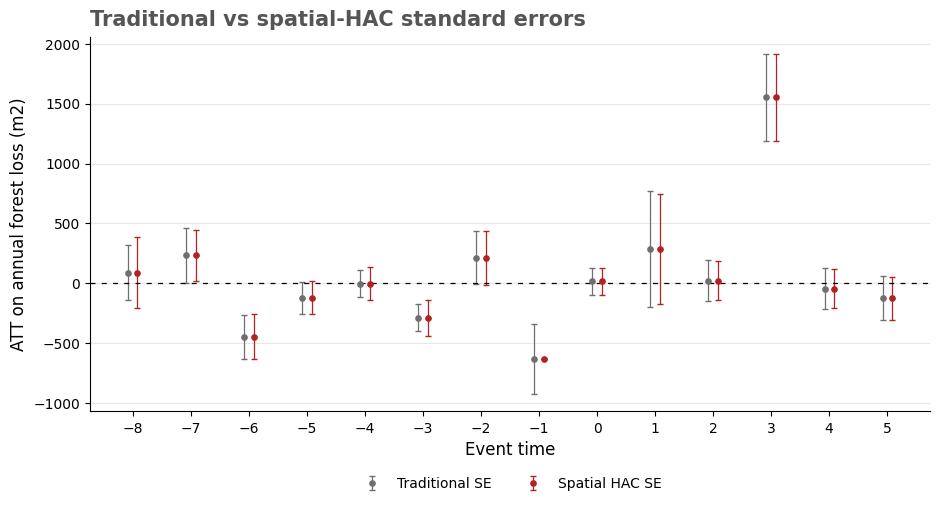

Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\figures\08_diffdiff_hac_se_comparison_1km.png


In [18]:
hac_se_comparison = pd.DataFrame()
if not diffdiff_gt.empty and not spatial_hac.empty:
    traditional = diffdiff_gt.loc[diffdiff_gt['covariate_set'] == 'none', ['group', 'time', 'att', 'se']].copy()
    traditional = traditional.rename(columns={'att': 'att_diffdiff', 'se': 'se_traditional'})
    for col in ['group', 'time', 'att_diffdiff', 'se_traditional']:
        traditional[col] = pd.to_numeric(traditional[col], errors='coerce')

    hac = spatial_hac[['group', 'time', 'event_time', 'att_no_covariate_recomputed', 'spatial_hac_se', 'hac_n_units', 'hac_n_pairs_used', 'hac_truncated']].copy()
    for col in ['group', 'time', 'event_time', 'att_no_covariate_recomputed', 'spatial_hac_se']:
        hac[col] = pd.to_numeric(hac[col], errors='coerce')

    hac_se_comparison = traditional.merge(hac, on=['group', 'time'], how='inner')
    hac_se_comparison = hac_se_comparison.dropna(subset=['att_diffdiff', 'se_traditional', 'spatial_hac_se']).copy()
    hac_se_comparison['se_ratio_hac_to_traditional'] = hac_se_comparison['spatial_hac_se'] / hac_se_comparison['se_traditional']
    hac_se_comparison['ci_low_traditional'] = hac_se_comparison['att_diffdiff'] - 1.96 * hac_se_comparison['se_traditional']
    hac_se_comparison['ci_high_traditional'] = hac_se_comparison['att_diffdiff'] + 1.96 * hac_se_comparison['se_traditional']
    hac_se_comparison['ci_low_spatial_hac'] = hac_se_comparison['att_diffdiff'] - 1.96 * hac_se_comparison['spatial_hac_se']
    hac_se_comparison['ci_high_spatial_hac'] = hac_se_comparison['att_diffdiff'] + 1.96 * hac_se_comparison['spatial_hac_se']
    hac_se_comparison['t_traditional'] = hac_se_comparison['att_diffdiff'] / hac_se_comparison['se_traditional']
    hac_se_comparison['t_spatial_hac'] = hac_se_comparison['att_diffdiff'] / hac_se_comparison['spatial_hac_se']
    hac_se_comparison['p_traditional'] = hac_se_comparison['t_traditional'].apply(lambda x: math.erfc(abs(x) / math.sqrt(2.0)) if np.isfinite(x) else np.nan)
    hac_se_comparison['p_spatial_hac'] = hac_se_comparison['t_spatial_hac'].apply(lambda x: math.erfc(abs(x) / math.sqrt(2.0)) if np.isfinite(x) else np.nan)
    hac_se_comparison['sig_traditional'] = hac_se_comparison['p_traditional'].apply(significance_stars)
    hac_se_comparison['sig_spatial_hac'] = hac_se_comparison['p_spatial_hac'].apply(significance_stars)

hac_compare_path = TABLE_DIR / append_tag_to_filename(HAC_SE_COMPARISON_NAME, RUN_TAG)
hac_se_comparison.to_csv(hac_compare_path, index=False)
print('Saved:', hac_compare_path)
if hac_se_comparison.empty:
    print('No traditional vs spatial-HAC comparison created.')
else:
    summary = hac_se_comparison['se_ratio_hac_to_traditional'].describe(percentiles=[0.25, 0.5, 0.75])
    print('HAC / traditional SE ratio summary:')
    print(summary.to_string())
    print(hac_se_comparison[['group', 'time', 'event_time', 'att_diffdiff', 'se_traditional', 'spatial_hac_se', 'se_ratio_hac_to_traditional', 'sig_traditional', 'sig_spatial_hac']].head(12).to_string(index=False))

if not hac_se_comparison.empty:
    def combine_compare_se(x):
        x = pd.to_numeric(x, errors='coerce').dropna()
        return np.sqrt(np.square(x).sum()) / len(x) if len(x) else np.nan

    event_compare = (
        hac_se_comparison.loc[hac_se_comparison['event_time'].between(EVENT_WINDOW_MIN, EVENT_WINDOW_MAX)]
        .groupby('event_time', as_index=False)
        .agg(
            att=('att_diffdiff', 'mean'),
            se_traditional=('se_traditional', combine_compare_se),
            se_spatial_hac=('spatial_hac_se', combine_compare_se),
            n_effects=('att_diffdiff', 'size'),
        )
        .sort_values('event_time')
    )
    if not event_compare.empty:
        fig, ax = plt.subplots(figsize=(9.5, 5.2))
        offset = 0.08
        ax.errorbar(event_compare['event_time'] - offset, event_compare['att'], yerr=1.96 * event_compare['se_traditional'], fmt='o', color='#6f6f6f', ecolor='#6f6f6f', elinewidth=0.9, capsize=2.5, markersize=3.8, label='Traditional SE')
        ax.errorbar(event_compare['event_time'] + offset, event_compare['att'], yerr=1.96 * event_compare['se_spatial_hac'], fmt='o', color='#b22222', ecolor='#b22222', elinewidth=0.9, capsize=2.5, markersize=3.8, label='Spatial HAC SE')
        ax.axhline(0, color='black', linewidth=0.9, linestyle=(0, (4, 5)))
        ax.set_title('Traditional vs spatial-HAC standard errors', loc='left', color='#555555', fontsize=15, weight='bold', pad=8)
        ax.set_xlabel('Event time', fontsize=12)
        ax.set_ylabel('ATT on annual forest loss (m2)', fontsize=12)
        ax.set_xticks(range(EVENT_WINDOW_MIN, EVENT_WINDOW_MAX + 1))
        ax.grid(True, axis='y', color='#e7e7e7', linewidth=0.8)
        ax.grid(False, axis='x')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2)
        fig.tight_layout()
        hac_compare_fig_path = FIG_DIR / append_tag_to_filename(HAC_SE_COMPARISON_FIG_NAME, RUN_TAG)
        fig.savefig(hac_compare_fig_path, dpi=220, bbox_inches='tight')
        plt.show()
        print('Saved:', hac_compare_fig_path)


**Intuition.** Traditional standard errors are the estimator's default uncertainty measure for the staggered-DiD ATT(g,t). They are appropriate when the residual/influence variation is treated as independent under that default sampling structure. Spatial-HAC standard errors ask a different question: what if nearby grid cells have correlated shocks because forest loss, enforcement, accessibility, weather, fire, land markets, or spillovers are spatially clustered? When nearby cells move together, they contain less independent information than the raw cell count suggests, so spatial-HAC standard errors are often larger and significance can weaken. If the spatial correlation is weak, negative, or the HAC recomputation uses a different no-covariate influence-function approximation, HAC standard errors can be similar to or smaller than the traditional ones. The point estimates do not change in this comparison; only the uncertainty calculation changes.

## Optional exploratory triple difference

`diff-diff`'s triple-difference estimator is a binary group x partition x post design. This block is off by default because it is not a staggered C&S replacement. Use it as a diagnostic after choosing a meaningful binary post period.

In [ ]:
ddd_results = pd.DataFrame()
if RUN_TRIPLE_DIFFERENCE:
    try:
        from diff_diff import TripleDifference
    except ImportError as exc:
        raise ImportError('Install estimator dependencies with `%pip install -r ../requirements.txt` before running the DDD block.') from exc

    required_ddd_cols = {DDD_GROUP_COL, DDD_PARTITION_COL}
    missing_ddd_cols = sorted(required_ddd_cols - set(panel.columns))
    if missing_ddd_cols:
        raise ValueError(f'Missing DDD columns in panel: {missing_ddd_cols}')
    ddd_df = panel[[CELL_COL, YEAR_COL, OUTCOME_COL, DDD_GROUP_COL, DDD_PARTITION_COL]].dropna().copy()
    ddd_df['post_period'] = (ddd_df[YEAR_COL] >= DDD_POST_YEAR).astype(int)
    ddd_df['ddd_group'] = ddd_df[DDD_GROUP_COL].astype(int)
    ddd_df['ddd_partition'] = ddd_df[DDD_PARTITION_COL].astype(int)

    ddd = TripleDifference()
    ddd_fit = ddd.fit(
        data=ddd_df,
        outcome=OUTCOME_COL,
        unit=CELL_COL,
        time=YEAR_COL,
        treatment='ddd_group',
        post='post_period',
        partition='ddd_partition',
    )
    ddd_results = pd.DataFrame([{
        'post_year': DDD_POST_YEAR,
        'group_col': DDD_GROUP_COL,
        'partition_col': DDD_PARTITION_COL,
        'ddd_estimate': getattr(ddd_fit, 'ddd_estimate', getattr(ddd_fit, 'effect', np.nan)),
        'standard_error': getattr(ddd_fit, 'standard_error', getattr(ddd_fit, 'se', np.nan)),
    }])
    ddd_path = TABLE_DIR / append_tag_to_filename(DDD_RESULTS_NAME, RUN_TAG)
    ddd_results.to_csv(ddd_path, index=False)
    print('Saved:', ddd_path)
    print(ddd_results.to_string(index=False))
else:
    print('Triple-difference block skipped. Set RUN_TRIPLE_DIFFERENCE = True after choosing DDD_POST_YEAR and the group/partition definitions.')


## Comparison table and event-study figure

Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\tables\08_diffdiff_csdid_comparison_1km.csv
covariate_set  group  time         att        se  att_csdid  se_csdid  att_difference_diffdiff_minus_csdid
         none   2002  2002  -28.803935 21.890666   -28.8039   21.8904                            -0.000035
         none   2002  2003  469.121776 18.441983   469.1218   18.4417                            -0.000024
         none   2002  2004 -263.287354 22.705680  -263.2874   22.7054                             0.000046
         none   2002  2005  105.779217 21.170242   105.7792   21.1700                             0.000017
         none   2002  2006  405.423801 21.709019   405.4238   21.7086                             0.000001
         none   2002  2007 -431.523843 25.907806  -431.5238   25.9076                            -0.000043
         none   2002  2008 -397.158533 27.894514  -397.1585   27.8942                            -0.000033
         none   2002  2009

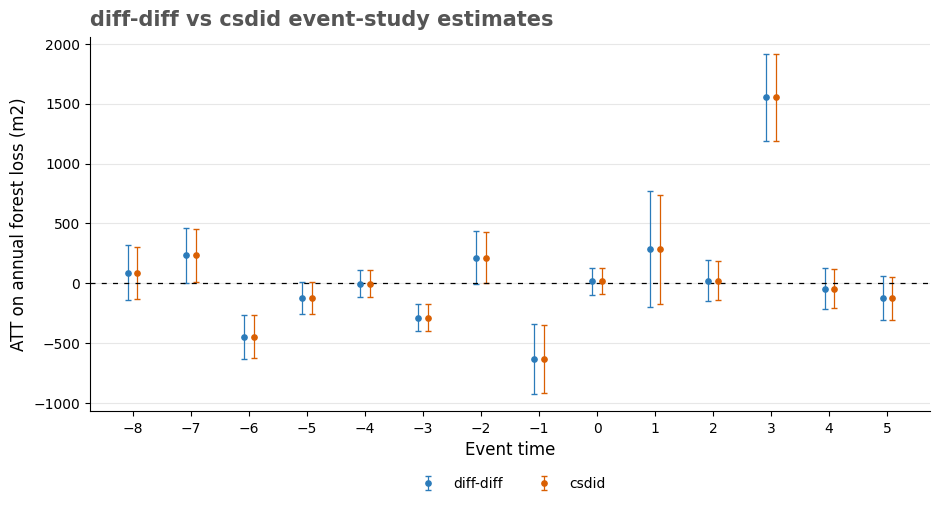

Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\figures\08_diffdiff_csdid_event_comparison_1km.png
Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\tables\08_diffdiff_cohort_effects_1km.csv
 group          att         se  n_group_time_effects          t             p       ci_low      ci_high significance
  2002  -214.012727   6.766419                    24 -31.628654 1.490922e-219  -227.274909  -200.750546          ***
  2003  -115.589148  56.736684                    23  -2.037291  4.162087e-02  -226.793048    -4.385247            *
  2004  -368.025480 105.376517                    22  -3.492481  4.785557e-04  -574.563452  -161.487507          ***
  2005  -132.069523  32.107264                    21  -4.113385  3.899002e-05  -194.999761   -69.139285          ***
  2006  -766.332539  94.890797                    20  -8.075942  6.695789e-16  -952.318500  -580.346577          ***
  2007  -754.612562  12.691981                    19 -59.

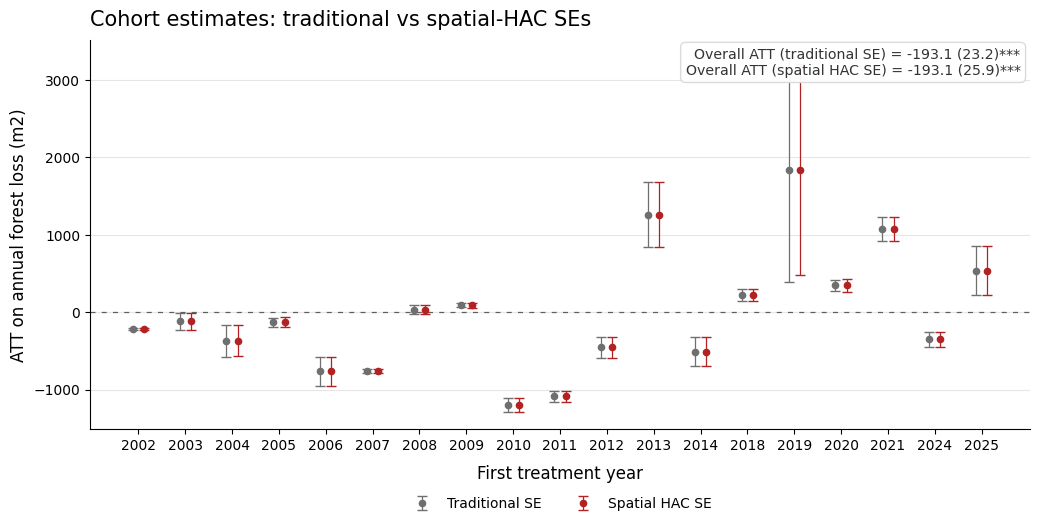

Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\figures\08_diffdiff_cohort_hac_se_comparison_1km.png


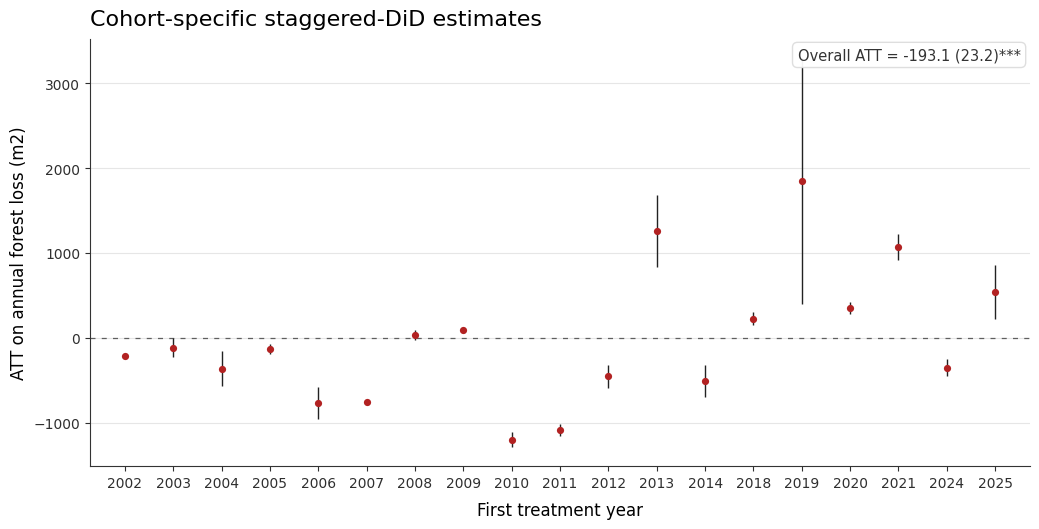

Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\figures\08_diffdiff_cohort_effects_1km.png


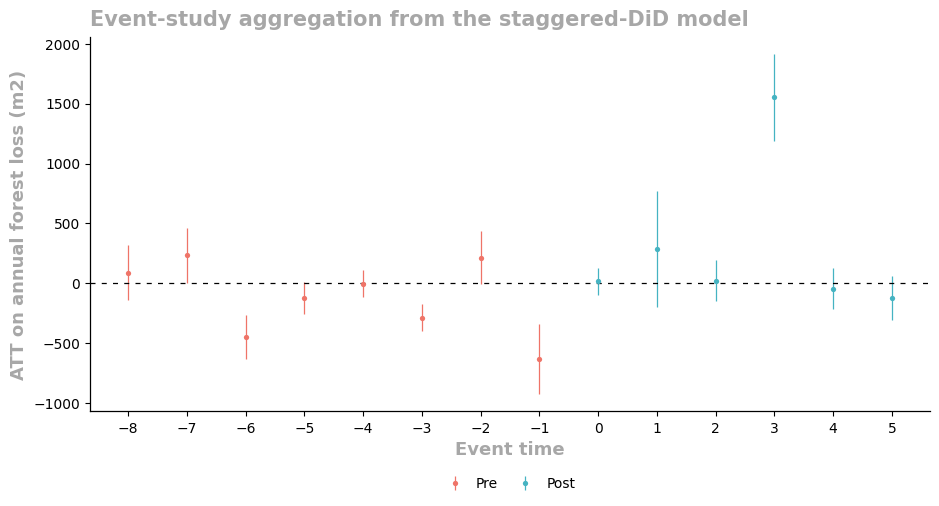

Saved: c:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\figures\08_diffdiff_event_study_1km.png
Note: package standard errors, csdid comparison output, and the no-covariate spatial-HAC inference layer are saved separately. Covariate-adjusted HAC remains tied to the availability of covariate-adjusted influence functions.


In [26]:
comparison = pd.DataFrame()
if not diffdiff_gt.empty and not csdid_gt.empty:
    dd = diffdiff_gt[diffdiff_gt['covariate_set'] == 'none'].copy()
    cs = csdid_gt.rename(columns={'Group': 'group', 'Time': 'time', 'ATT(g, t)': 'att_csdid', 'Std. Error': 'se_csdid'})
    for col in ['group', 'time']:
        if col in cs.columns:
            cs[col] = pd.to_numeric(cs[col], errors='coerce')
    comparison = dd.merge(cs[[c for c in ['group', 'time', 'att_csdid', 'se_csdid'] if c in cs.columns]], on=['group', 'time'], how='inner')
    comparison['att_difference_diffdiff_minus_csdid'] = comparison['att'] - comparison['att_csdid']
comparison_path = TABLE_DIR / append_tag_to_filename(COMPARISON_NAME, RUN_TAG)
comparison.to_csv(comparison_path, index=False)
print('Saved:', comparison_path)
print(comparison.head(12).to_string(index=False) if not comparison.empty else 'No comparison table created.')

if not comparison.empty:
    cs_plot = comparison.copy()
    cs_plot['event_time'] = pd.to_numeric(cs_plot['time'], errors='coerce') - pd.to_numeric(cs_plot['group'], errors='coerce')
    for col in ['att', 'se', 'att_csdid', 'se_csdid']:
        if col in cs_plot.columns:
            cs_plot[col] = pd.to_numeric(cs_plot[col], errors='coerce')
    cs_plot = cs_plot.dropna(subset=['event_time', 'att', 'att_csdid'])
    cs_plot = cs_plot.loc[cs_plot['event_time'].between(EVENT_WINDOW_MIN, EVENT_WINDOW_MAX)]
    if not cs_plot.empty:
        def combine_plot_se(x):
            x = pd.to_numeric(x, errors='coerce').dropna()
            return np.sqrt(np.square(x).sum()) / len(x) if len(x) else np.nan

        cs_event = (
            cs_plot.groupby('event_time', as_index=False)
            .agg(
                att_diffdiff=('att', 'mean'),
                se_diffdiff=('se', combine_plot_se),
                att_csdid=('att_csdid', 'mean'),
                se_csdid=('se_csdid', combine_plot_se),
                n_effects=('att', 'size'),
            )
            .sort_values('event_time')
        )
        fig, ax = plt.subplots(figsize=(9.5, 5.2))
        offset = 0.08
        ax.errorbar(cs_event['event_time'] - offset, cs_event['att_diffdiff'], yerr=1.96 * cs_event['se_diffdiff'], fmt='o', color='#2b7bba', ecolor='#2b7bba', elinewidth=0.9, capsize=2.5, markersize=3.8, label='diff-diff')
        ax.errorbar(cs_event['event_time'] + offset, cs_event['att_csdid'], yerr=1.96 * cs_event['se_csdid'], fmt='o', color='#d95f02', ecolor='#d95f02', elinewidth=0.9, capsize=2.5, markersize=3.8, label='csdid')
        ax.axhline(0, color='black', linewidth=0.9, linestyle=(0, (4, 5)))
        ax.set_title('diff-diff vs csdid event-study estimates', loc='left', color='#555555', fontsize=15, weight='bold', pad=8)
        ax.set_xlabel('Event time', fontsize=12)
        ax.set_ylabel('ATT on annual forest loss (m2)', fontsize=12)
        ax.set_xticks(range(EVENT_WINDOW_MIN, EVENT_WINDOW_MAX + 1))
        ax.grid(True, axis='y', color='#e7e7e7', linewidth=0.8)
        ax.grid(False, axis='x')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2)
        fig.tight_layout()
        csdid_fig_path = FIG_DIR / append_tag_to_filename(CSDID_EVENT_COMPARISON_FIG_NAME, RUN_TAG)
        fig.savefig(csdid_fig_path, dpi=220, bbox_inches='tight')
        plt.show()
        print('Saved:', csdid_fig_path)
else:
    print('csdid event-study comparison figure skipped because the comparison table is empty.')

cohort_effects = pd.DataFrame()
cohort_fig_path = FIG_DIR / append_tag_to_filename(COHORT_FIG_NAME, RUN_TAG)
cohort_path = TABLE_DIR / append_tag_to_filename(COHORT_EFFECTS_NAME, RUN_TAG)
if not diffdiff_gt.empty:
    cohort_source = diffdiff_gt.loc[diffdiff_gt['covariate_set'] == 'none'].copy()
    for col in ['group', 'time', 'att', 'se']:
        cohort_source[col] = pd.to_numeric(cohort_source[col], errors='coerce')
    cohort_source = cohort_source.dropna(subset=['group', 'time', 'att'])
    cohort_source = cohort_source.loc[cohort_source['time'] >= cohort_source['group']]
    if not cohort_source.empty:
        def combine_group_se(x):
            x = pd.to_numeric(x, errors='coerce').dropna()
            return np.sqrt(np.square(x).sum()) / len(x) if len(x) else np.nan

        cohort_effects = (
            cohort_source.groupby('group', as_index=False)
            .agg(att=('att', 'mean'), se=('se', combine_group_se), n_group_time_effects=('att', 'size'))
            .sort_values('group')
        )
        cohort_effects['t'] = cohort_effects['att'] / cohort_effects['se']
        cohort_effects['p'] = cohort_effects['t'].apply(lambda x: math.erfc(abs(x) / math.sqrt(2.0)) if np.isfinite(x) else np.nan)
        cohort_effects['ci_low'] = cohort_effects['att'] - 1.96 * cohort_effects['se']
        cohort_effects['ci_high'] = cohort_effects['att'] + 1.96 * cohort_effects['se']
        cohort_effects['significance'] = cohort_effects['p'].apply(significance_stars)
cohort_effects.to_csv(cohort_path, index=False)
print('Saved:', cohort_path)
print(cohort_effects.to_string(index=False) if not cohort_effects.empty else 'No cohort-specific table created.')

overall_display = diffdiff_overall.loc[diffdiff_overall['covariate_set'] == 'none'].copy() if not diffdiff_overall.empty else pd.DataFrame()
if not overall_display.empty:
    print('Overall ATT summary:')
    print(overall_display[['overall_att', 'overall_se', 'overall_t', 'overall_p', 'ci_low', 'ci_high', 'significance']].to_string(index=False))

cohort_hac_comparison = pd.DataFrame()
overall_hac_comparison = pd.DataFrame()
if 'hac_se_comparison' in globals() and not hac_se_comparison.empty:
    post_hac = hac_se_comparison.loc[hac_se_comparison['time'] >= hac_se_comparison['group']].copy()
    if not post_hac.empty:
        def combine_hac_plot_se(x):
            x = pd.to_numeric(x, errors='coerce').dropna()
            return np.sqrt(np.square(x).sum()) / len(x) if len(x) else np.nan

        cohort_hac_comparison = (
            post_hac.groupby('group', as_index=False)
            .agg(
                att=('att_diffdiff', 'mean'),
                se_traditional=('se_traditional', combine_hac_plot_se),
                se_spatial_hac=('spatial_hac_se', combine_hac_plot_se),
                n_group_time_effects=('att_diffdiff', 'size'),
            )
            .sort_values('group')
        )
        cohort_hac_comparison['se_ratio_hac_to_traditional'] = cohort_hac_comparison['se_spatial_hac'] / cohort_hac_comparison['se_traditional']
        cohort_hac_comparison['ci_low_traditional'] = cohort_hac_comparison['att'] - 1.96 * cohort_hac_comparison['se_traditional']
        cohort_hac_comparison['ci_high_traditional'] = cohort_hac_comparison['att'] + 1.96 * cohort_hac_comparison['se_traditional']
        cohort_hac_comparison['ci_low_spatial_hac'] = cohort_hac_comparison['att'] - 1.96 * cohort_hac_comparison['se_spatial_hac']
        cohort_hac_comparison['ci_high_spatial_hac'] = cohort_hac_comparison['att'] + 1.96 * cohort_hac_comparison['se_spatial_hac']
        cohort_hac_comparison['p_traditional'] = (cohort_hac_comparison['att'] / cohort_hac_comparison['se_traditional']).apply(lambda x: math.erfc(abs(x) / math.sqrt(2.0)) if np.isfinite(x) else np.nan)
        cohort_hac_comparison['p_spatial_hac'] = (cohort_hac_comparison['att'] / cohort_hac_comparison['se_spatial_hac']).apply(lambda x: math.erfc(abs(x) / math.sqrt(2.0)) if np.isfinite(x) else np.nan)
        cohort_hac_comparison['sig_traditional'] = cohort_hac_comparison['p_traditional'].apply(significance_stars)
        cohort_hac_comparison['sig_spatial_hac'] = cohort_hac_comparison['p_spatial_hac'].apply(significance_stars)

        if not overall_display.empty:
            overall_row = overall_display.iloc[0]
            overall_att = float(overall_row['overall_att'])
            se_traditional = float(overall_row['overall_se'])
            se_spatial_hac = combine_hac_plot_se(post_hac['spatial_hac_se'])
            overall_hac_comparison = pd.DataFrame([{
                'att': overall_att,
                'se_traditional': se_traditional,
                'se_spatial_hac_approx': se_spatial_hac,
                'se_ratio_hac_to_traditional': se_spatial_hac / se_traditional if np.isfinite(se_traditional) and se_traditional > 0 else np.nan,
                'p_traditional': float(overall_row['overall_p']),
                'p_spatial_hac_approx': math.erfc(abs(overall_att / se_spatial_hac) / math.sqrt(2.0)) if np.isfinite(se_spatial_hac) and se_spatial_hac > 0 else np.nan,
                'sig_traditional': overall_row['significance'],
                'sig_spatial_hac_approx': significance_stars(math.erfc(abs(overall_att / se_spatial_hac) / math.sqrt(2.0)) if np.isfinite(se_spatial_hac) and se_spatial_hac > 0 else np.nan),
                'note': 'Approximate HAC overall SE from marginal post-treatment ATT(g,t) HAC SEs; full cross-effect HAC covariance is not estimated here.',
            }])

cohort_hac_path = TABLE_DIR / append_tag_to_filename(COHORT_HAC_SE_COMPARISON_NAME, RUN_TAG)
cohort_hac_comparison.to_csv(cohort_hac_path, index=False)
print('Saved:', cohort_hac_path)
print(cohort_hac_comparison.to_string(index=False) if not cohort_hac_comparison.empty else 'No cohort HAC SE comparison created.')

overall_hac_path = TABLE_DIR / append_tag_to_filename(OVERALL_HAC_SE_COMPARISON_NAME, RUN_TAG)
overall_hac_comparison.to_csv(overall_hac_path, index=False)
print('Saved:', overall_hac_path)
print(overall_hac_comparison.to_string(index=False) if not overall_hac_comparison.empty else 'No overall HAC SE comparison created.')

if not cohort_hac_comparison.empty:
    fig, ax = plt.subplots(figsize=(10.5, 5.4))
    x_pos = np.arange(len(cohort_hac_comparison))
    offset = 0.12
    ax.errorbar(x_pos - offset, cohort_hac_comparison['att'], yerr=1.96 * cohort_hac_comparison['se_traditional'], fmt='o', color='#6f6f6f', ecolor='#6f6f6f', elinewidth=0.9, capsize=3.5, markersize=4.5, label='Traditional SE')
    ax.errorbar(x_pos + offset, cohort_hac_comparison['att'], yerr=1.96 * cohort_hac_comparison['se_spatial_hac'], fmt='o', color='#b22222', ecolor='#b22222', elinewidth=0.9, capsize=3.5, markersize=4.5, label='Spatial HAC SE')
    ax.axhline(0, color='#5f5f5f', linewidth=0.9, linestyle=(0, (4, 5)))
    ax.set_title('Cohort estimates: traditional vs spatial-HAC SEs', loc='left', fontsize=15, pad=10)
    ax.set_xlabel('First treatment year', fontsize=12, labelpad=8)
    ax.set_ylabel('ATT on annual forest loss (m2)', fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(cohort_hac_comparison['group'].astype(int).astype(str), rotation=0)
    ax.grid(True, axis='y', color='#e6e6e6', linewidth=0.8)
    ax.grid(False, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if not overall_hac_comparison.empty:
        overall_row = overall_hac_comparison.iloc[0]
        overall_note = (
            f"Overall ATT (traditional SE) = {overall_row['att']:.1f} "
            f"({overall_row['se_traditional']:.1f}){overall_row['sig_traditional']}\n"
            f"Overall ATT (spatial HAC SE) = {overall_row['att']:.1f} "
            f"({overall_row['se_spatial_hac_approx']:.1f}){overall_row['sig_spatial_hac_approx']}"
        )
        ax.text(
            0.99,
            0.98,
            overall_note,
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=10.2,
            color='#333333',
            bbox=dict(facecolor='white', edgecolor='#d9d9d9', boxstyle='round,pad=0.35', alpha=0.95),
        )
    ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2)
    fig.tight_layout()
    cohort_hac_fig_path = FIG_DIR / append_tag_to_filename(COHORT_HAC_SE_COMPARISON_FIG_NAME, RUN_TAG)
    fig.savefig(cohort_hac_fig_path, dpi=220, bbox_inches='tight')
    plt.show()
    print('Saved:', cohort_hac_fig_path)

if not cohort_effects.empty:
    fig, ax = plt.subplots(figsize=(10.5, 5.4))
    x_pos = np.arange(len(cohort_effects))
    yerr = 1.96 * cohort_effects['se'].to_numpy(dtype=float)
    yerr = np.where(np.isfinite(yerr), yerr, 0.0)
    ax.errorbar(
        x_pos,
        cohort_effects['att'],
        yerr=yerr,
        fmt='o',
        color='#b22222',
        ecolor='#222222',
        elinewidth=1.0,
        capsize=4.5,
        markersize=5.2,
        markeredgewidth=0,
        zorder=3,
    )
    ax.axhline(0, color='#5f5f5f', linewidth=0.9, linestyle=(0, (4, 5)), zorder=2)
    ax.set_title('Cohort-specific staggered-DiD estimates', loc='left', fontsize=16, pad=10)
    ax.set_xlabel('First treatment year', fontsize=12, labelpad=8)
    ax.set_ylabel('ATT on annual forest loss (m2)', fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(cohort_effects['group'].astype(int).astype(str), rotation=0)
    ax.grid(True, axis='y', color='#e6e6e6', linewidth=0.8)
    ax.grid(False, axis='x')
    ax.margins(x=0.04)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    ax.tick_params(axis='both', labelsize=10, colors='#2f2f2f')
    if not overall_display.empty:
        overall_row = overall_display.iloc[0]
        label = f"Overall ATT = {overall_row['overall_att']:.1f} ({overall_row['overall_se']:.1f}){overall_row['significance']}"
        ax.text(
            0.99,
            0.98,
            label,
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=10.5,
            color='#333333',
            bbox=dict(facecolor='white', edgecolor='#dddddd', boxstyle='round,pad=0.35', alpha=0.95),
        )
    fig.tight_layout()
    fig.savefig(cohort_fig_path, dpi=220, bbox_inches='tight')
    plt.show()
    print('Saved:', cohort_fig_path)

fig_path = FIG_DIR / append_tag_to_filename(EVENT_FIG_NAME, RUN_TAG)
if not diffdiff_gt.empty:
    es = diffdiff_gt.copy()
    es['event_time'] = pd.to_numeric(es['time'], errors='coerce') - pd.to_numeric(es['group'], errors='coerce')
    es['att'] = pd.to_numeric(es['att'], errors='coerce')
    es['se'] = pd.to_numeric(es['se'], errors='coerce')
    es = es.dropna(subset=['event_time', 'att'])
    es = es.loc[es['event_time'].between(EVENT_WINDOW_MIN, EVENT_WINDOW_MAX)].copy()
    if es.empty:
        print('Event-study figure skipped because there are no valid numeric ATT rows.')
    else:
        def combine_se(x):
            x = pd.to_numeric(x, errors='coerce').dropna()
            return np.sqrt(np.square(x).sum()) / len(x) if len(x) else np.nan

        plot_df = (
            es.groupby('event_time', as_index=False)
            .agg(att=('att', 'mean'), se=('se', combine_se))
            .sort_values('event_time')
        )
        plot_df['period'] = np.where(plot_df['event_time'] < 0, 'Pre', 'Post')
        colors = {'Pre': '#ef7468', 'Post': '#45b3c2'}

        fig, ax = plt.subplots(figsize=(9.5, 5.2))
        for period, part in plot_df.groupby('period', sort=False):
            yerr = 1.96 * part['se'].to_numpy(dtype=float)
            yerr = np.where(np.isfinite(yerr), yerr, 0.0)
            ax.errorbar(
                part['event_time'],
                part['att'],
                yerr=yerr,
                fmt='o',
                color=colors[period],
                ecolor=colors[period],
                elinewidth=0.9,
                capsize=2.5,
                markersize=3.8,
                markeredgewidth=0,
                label=period,
            )
        ax.axhline(0, color='black', linewidth=0.9, linestyle=(0, (4, 5)))
        ax.set_title('Event-study aggregation from the staggered-DiD model', loc='left', color='#a7a7a7', fontsize=15, weight='bold', pad=8)
        ax.set_xlabel('Event time', color='#a7a7a7', fontsize=13, weight='bold')
        ax.set_ylabel('ATT on annual forest loss (m2)', color='#a7a7a7', fontsize=13, weight='bold')
        ax.set_xticks(range(EVENT_WINDOW_MIN, EVENT_WINDOW_MAX + 1))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.9)
        ax.spines['bottom'].set_linewidth(0.9)
        ax.tick_params(axis='both', labelsize=10)
        ax.grid(False)
        ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2, handlelength=1.5, columnspacing=1.2)
        fig.tight_layout()
        fig.savefig(fig_path, dpi=220, bbox_inches='tight')
        plt.show()
        print('Saved:', fig_path)

print('Note: package standard errors, csdid comparison output, and the no-covariate spatial-HAC inference layer are saved separately. Covariate-adjusted HAC remains tied to the availability of covariate-adjusted influence functions.')
